In [1]:
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import load_model

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Trained Model
print("Loading the transfer learning model...")
model = load_model("cross_section_transfer_model.keras")
print("Model loaded successfully.\n")

# 2. Load the Feature Scaler
print("Loading the feature scaler...")
scaler = joblib.load("feature_scaler.joblib")
print(f"Scaler loaded. (Mean: {scaler.mean_}, Scale/Std: {scaler.scale_})\n")

# 3. Load the Training History
print("Loading training history...")
history_data = np.load("training_history.npz")
history_fit_loss = history_data['history_fit_loss']
history_fit_val_loss = history_data['history_fit_val_loss']
history_raw_loss = history_data['history_raw_loss']
history_raw_val_loss = history_data['history_raw_val_loss']
print(f"History loaded. Phase 1 (Fit) ran for {len(history_fit_loss)} epochs.")
print(f"History loaded. Phase 2 (Raw) ran for {len(history_raw_loss)} epochs.\n")

# 4. Load the Train/Test Datasets
print("Loading train and test datasets...")
train_test_data = np.load("train_test_data.npz")

# Extract Fitted data splits
Xfit_train = train_test_data['Xfit_train']
yfit_train = train_test_data['yfit_train']
Xfit_test = train_test_data['Xfit_test']
yfit_test = train_test_data['yfit_test']

# Extract Raw data splits
Xraw_train = train_test_data['Xraw_train']
yraw_train = train_test_data['yraw_train']
Xraw_test = train_test_data['Xraw_test']
yraw_test = train_test_data['yraw_test']

print("Datasets loaded successfully!")
print(f"  - Fitted Training X shape: {Xfit_train.shape}")
print(f"  - Raw Testing X shape: {Xraw_test.shape}")

I0000 00:00:1773917395.629187 3254071 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773917395.682959 3254071 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773917396.790732 3254071 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading the transfer learning model...


W0000 00:00:1773917397.820554 3254147 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773917397.901887 3254071 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model loaded successfully.

Loading the feature scaler...
Scaler loaded. (Mean: [  8.22641979   3.5861579    8.64326468  12.3462638  482.5225053 ], Scale/Std: [  3.58490945   3.07690778   7.77018736   9.59585337 243.28865926])

Loading training history...
History loaded. Phase 1 (Fit) ran for 43 epochs.
History loaded. Phase 2 (Raw) ran for 10 epochs.

Loading train and test datasets...
Datasets loaded successfully!
  - Fitted Training X shape: (37535451, 5)
  - Raw Testing X shape: (508230, 5)


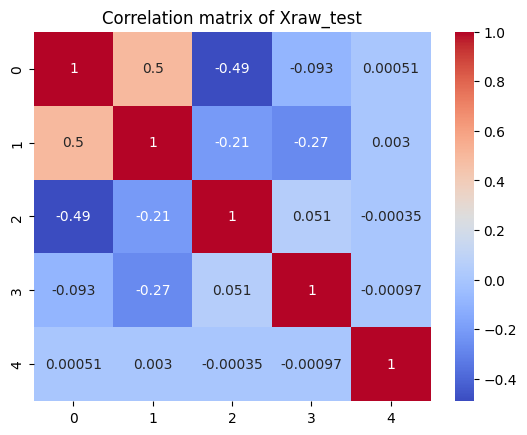

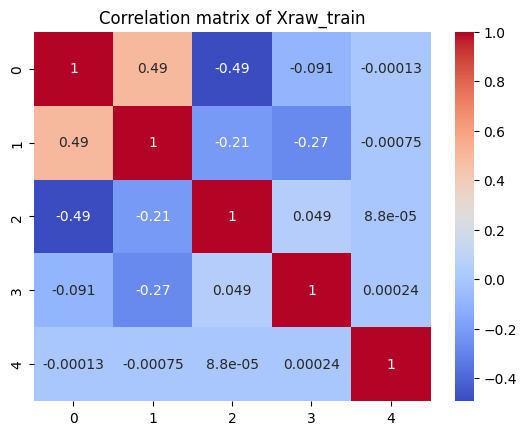

In [2]:
# check Xraw correlation plot
sns.heatmap(np.corrcoef(Xraw_test.T), annot=True, cmap='coolwarm')
plt.title('Correlation matrix of Xraw_test')
plt.show()

sns.heatmap(np.corrcoef(Xraw_train.T), annot=True, cmap='coolwarm')
plt.title('Correlation matrix of Xraw_train')
plt.show()

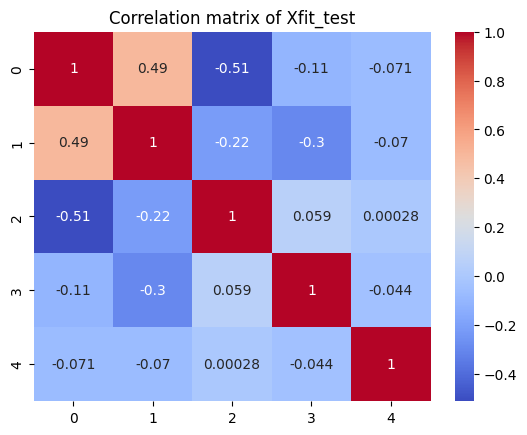

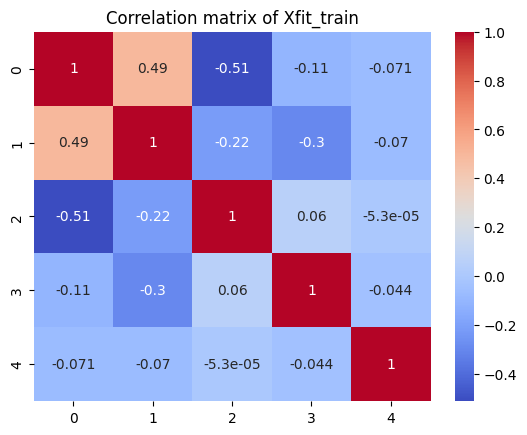

In [3]:
# check Xfit correlation plot
sns.heatmap(np.corrcoef(Xfit_test.T), annot=True, cmap='coolwarm')
plt.title('Correlation matrix of Xfit_test')
plt.show()

sns.heatmap(np.corrcoef(Xfit_train.T), annot=True, cmap='coolwarm')
plt.title('Correlation matrix of Xfit_train')
plt.show()

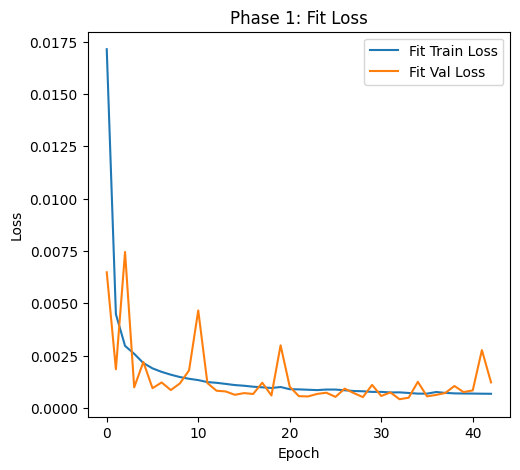

In [4]:
# plot history_data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_fit_loss, label='Fit Train Loss')
plt.plot(history_fit_val_loss, label='Fit Val Loss')
plt.title('Phase 1: Fit Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()    

In [5]:
y_pred_fit_test = model.predict(Xfit_test)
y_pred_fit_train = model.predict(Xfit_train)
y_pred_raw_test = model.predict(Xraw_test)
y_pred_raw_train = model.predict(Xraw_train)

293246/293246 ━━━━━━━━━━━━━━━━━━━━ 128s 435us/step
1172983/1172983 ━━━━━━━━━━━━━━━━━━━━ 522s 445us/step
15883/15883 ━━━━━━━━━━━━━━━━━━━━ 7s 428us/step
63529/63529 ━━━━━━━━━━━━━━━━━━━━ 28s 442us/step


In [12]:

import numpy as np

def calculate_metrics_in_chunks(y_true, y_pred, chunk_size=500000):
    """
    Calculates MAPE and RMSE in chunks, ensuring shapes match to prevent 
    broadcasting memory explosions.
    """
    # FIX: Flatten both arrays to ensure they are strictly 1D (shape: (N,))
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    
    n = len(y_true)
    sum_sq_error = 0.0
    sum_abs_perc_error = 0.0
    
    for i in range(0, n, chunk_size):
        y_true_chunk = y_true[i : i + chunk_size]
        y_pred_chunk = y_pred[i : i + chunk_size]
        
        # Calculate error for this chunk
        error = y_true_chunk - y_pred_chunk
        
        # Accumulate the sum of squared errors
        sum_sq_error += np.sum(error ** 2)
        
        # Accumulate the sum of absolute percentage errors
        sum_abs_perc_error += np.sum(np.abs(error / y_true_chunk))
        
    final_rmse = np.sqrt(sum_sq_error / n)
    final_mape = (sum_abs_perc_error / n) * 100
    
    return final_mape, final_rmse

# --- Execute for Test Data ---
fit_test_mape, fit_test_rmse = calculate_metrics_in_chunks(yfit_test, y_pred_fit_test)

# --- Execute for Train Data ---
fit_train_mape, fit_train_rmse = calculate_metrics_in_chunks(yfit_train, y_pred_fit_train)

print(f"Phase 1 (Fit)  Test MAPE: {fit_test_mape:.2f}%")
print(f"Phase 1 (Fit) Train MAPE: {fit_train_mape:.2f}%")
print(f"Phase 1 (Fit)  Test RMSE: {fit_test_rmse:.4f}")
print(f"Phase 1 (Fit) Train RMSE: {fit_train_rmse:.4f}")

Phase 1 (Fit)  Test MAPE: 254930122.66%
Phase 1 (Fit) Train MAPE: 289833141.89%
Phase 1 (Fit)  Test RMSE: 2122.4272
Phase 1 (Fit) Train RMSE: 2122.4708
